
# TRAINING TEXT CLASSIFIERS WITH SPACY

In this lab we will train different text classifiers with spacy.

1. Read through the code and train to add more inline documentation as you try to understand the functionality.

2. We will adapt the code to train two different fake news classifiers: one on general fake news from 5 different domains and another one on celebrities, were there are legitimate news but also news which are false gossip.



In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# We will be using spacy v3
!pip install -U spacy
!pip install -U spacy-transformers

## 1. Load the dataset into a pandas dataframe

In [21]:
import spacy
#import spacy_transformers
import csv
import random
import time
import numpy as np
import pandas as pd
import re
import string
import seaborn as sns

from spacy.util import minibatch, compounding
import sys
from spacy import displacy
from itertools import chain

from sklearn.metrics import classification_report

# TODO add inline documentation describing the functionality of each function
# load data

def load_data(fnames):
    """
    Loads TSV files from a list of file paths into a single concatenated
    DataFrame. Also returns a list of unique label values from the 'Target'
    column.
    """
    data = []
    for fname in fnames:
        data.append(pd.read_csv(fname, sep='\t', encoding='utf-8'))
    data = pd.concat(data)
    targets = set(data['Target'])
    return data, list(targets)


def cleanup(tweet):
    """
    Pre-processes tweets by removing URLs, hashtag (#) symbols,
    and mention (@) symbols. Keeps the text of hashtags/mentions.
    """
    tweet = re.sub(r"http\S+", "", tweet.replace("#", "").replace("@", ""))
    return tweet

In [22]:
# data path. trial data used as training too.
trial_file = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/semeval2016-task6-trialdata.utf-8.txt"
train_file = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/semeval2016-task6-trainingdata.utf-8.txt"
test_file = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/SemEval2016-Task6-subtaskA-testdata-gold.txt"

training_data, targets = load_data([trial_file, train_file])
training_data['Clean_tweet'] = training_data['Tweet'].apply(cleanup)

test_data, _ = load_data([test_file])
test_data['Clean_tweet'] = test_data['Tweet'].apply(cleanup)
display(training_data)

,ID,Target,Tweet,Stance,Clean_tweet
0,1,Hillary Clinton,"@tedcruz And, #HandOverTheServer she wiped cle...",AGAINST,"tedcruz And, HandOverTheServer she wiped clean..."
1,2,Hillary Clinton,Hillary is our best choice if we truly want to...,FAVOR,Hillary is our best choice if we truly want to...
2,3,Hillary Clinton,@TheView I think our country is ready for a fe...,AGAINST,TheView I think our country is ready for a fem...
3,4,Hillary Clinton,I just gave an unhealthy amount of my hard-ear...,AGAINST,I just gave an unhealthy amount of my hard-ear...
4,5,Hillary Clinton,@PortiaABoulger Thank you for adding me to you...,NONE,PortiaABoulger Thank you for adding me to your...
...,...,...,...,...,...
2809,2910,Legalization of Abortion,"There's a law protecting unborn eagles, but no...",AGAINST,"There's a law protecting unborn eagles, but no..."
2810,2911,Legalization of Abortion,I am 1 in 3... I have had an abortion #Abortio...,AGAINST,I am 1 in 3... I have had an abortion Abortion...
2811,2912,Legalization of Abortion,How dare you say my sexual preference is a cho...,AGAINST,How dare you say my sexual preference is a cho...
2812,2913,Legalization of Abortion,"Equal rights for those 'born that way', no rig...",AGAINST,"Equal rights for those 'born that way', no rig..."


In [23]:
training_data["Target"].unique()

array(['Hillary Clinton', 'Legalization of Abortion', 'Atheism',
       'Climate Change is a Real Concern', 'Feminist Movement'],
      dtype=object)

In [24]:
targets

['Feminist Movement',
 'Hillary Clinton',
 'Climate Change is a Real Concern',
 'Atheism',
 'Legalization of Abortion']

Exploring the dataset without taking into account the 5 different topics.

In [25]:
sns.set(font_scale=1.2)

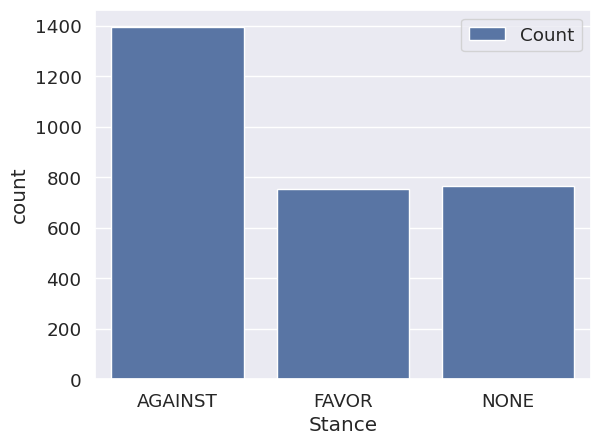

In [26]:
sns.countplot(x = training_data['Stance'], label = 'Count');

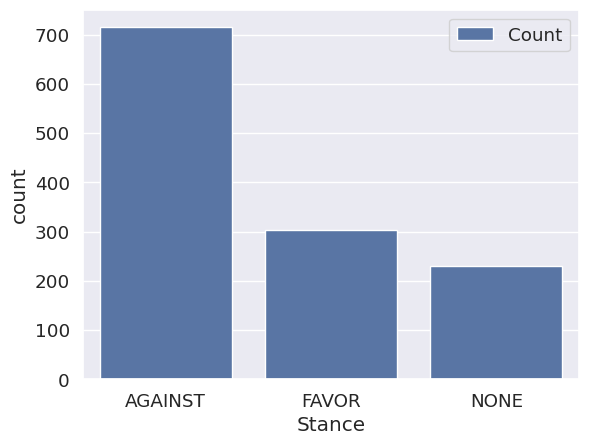

In [27]:
sns.countplot(x = test_data['Stance'], label = 'Count');

In [28]:
train = list(training_data[['Clean_tweet', 'Stance']].sample(frac=1).itertuples(index=False, name=None))
print(f"Training Example: {train[0]}")
print(f"Total Train: {len(train)}")

Training Example: ("luisaomielan amazing show in Leicester tonight, best comedy show I've ever seen, incredible! upgradeyourself SemST", 'NONE')
Total Train: 2914


In [29]:
test = list(test_data[['Clean_tweet', 'Stance']].sample(frac=1).itertuples(index=False, name=None))
print(f"Test Example: {test[1]}")
print(f"Total Test: {len(test)}")

Test Example: ("At the end of the day, support the candidate w/best chance of beating the progressive democrat.  Don't stay home.  UniteRight SemST", 'AGAINST')
Total Test: 1249


OPTIONAL: If you like to manually inspect the data, this code will allow you to save the datasets in CSV format for each of the topics.

In [30]:
# Create train and test tsv files for each topic in semeval2016 (only good for manually inspecting the data)
for target in targets:
  training_data[training_data['Target'] == target][['Stance', 'Clean_tweet']].to_csv(f"/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.{target}.tsv",
          sep="\t", index=False, quoting=csv.QUOTE_NONE, quotechar="", escapechar="\\")
  test_data[test_data['Target'] == target][['Stance', 'Clean_tweet']].to_csv(f"/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.{target}.tsv",
          sep="\t", index=False, quoting=csv.QUOTE_NONE, quotechar="", escapechar="\\")

## 2. Convert into spaCy binary format

We will first install and pipeline and initialize it. Since we are interested in good results, we will install the transformers pipeline for English.

In [31]:
# install spaCy pipelines
!python -m spacy download en_core_web_sm
#!python -m spacy download en_core_web_lg
#!python -m spacy download en_core_web_trf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [32]:
# Load the transformers pipeline
nlp = spacy.load("en_core_web_sm")
#nlp = spacy.load("en_core_web_lg")
#nlp = spacy.load("en_core_web_trf")

In [33]:
# load a blank pipeline
#nlp = spacy.blank("en")

We have already instantiated a spaCy pipeline because we need to use it to make the data conversion for training and testing, like so:

In [34]:
from collections import Counter
import pathlib
from spacy.tokens import DocBin

def convert_stance_to_spacy(data):
    """
    Converts a list of (text, label) tuples where label is one of
    AGAINST / FAVOR / NONE into spaCy Doc objects with .cats set.
    """
    nlp = spacy.blank("en")
    docs = []
    for doc, label in nlp.pipe(data, as_tuples=True):
        doc.cats = {"AGAINST": 0, "FAVOR": 0, "NONE": 0}
        if label in doc.cats:
            doc.cats[label] = 1
        docs.append(doc)
    return docs


base_spacy_output_dir = pathlib.Path(
    "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP-datasets/spacy_data"
)
base_spacy_output_dir.mkdir(parents=True, exist_ok=True)

for target in targets:
    train_dataset = list(
        training_data[training_data['Target'] == target][['Clean_tweet', 'Stance']]
        .itertuples(index=False, name=None)
    )
    label_counter = Counter(elem[1] for elem in train_dataset)
    print(f"{target} Training: {len(train_dataset)}, {label_counter}")

    train_docs = convert_stance_to_spacy(train_dataset)
    DocBin(docs=train_docs).to_disk(base_spacy_output_dir / f"train.{target}.spacy")

    test_dataset = list(
        test_data[test_data['Target'] == target][['Clean_tweet', 'Stance']]
        .itertuples(index=False, name=None)
    )
    label_counter = Counter(elem[1] for elem in test_dataset)
    print(f"{target} Test: {len(test_dataset)}, {label_counter}")

    test_docs = convert_stance_to_spacy(test_dataset)
    DocBin(docs=test_docs).to_disk(base_spacy_output_dir / f"test.{target}.spacy")

Feminist Movement Training: 664, Counter({'AGAINST': 328, 'FAVOR': 210, 'NONE': 126})
Feminist Movement Test: 285, Counter({'AGAINST': 183, 'FAVOR': 58, 'NONE': 44})
Hillary Clinton Training: 689, Counter({'AGAINST': 393, 'NONE': 178, 'FAVOR': 118})
Hillary Clinton Test: 295, Counter({'AGAINST': 172, 'NONE': 78, 'FAVOR': 45})
Climate Change is a Real Concern Training: 395, Counter({'FAVOR': 212, 'NONE': 168, 'AGAINST': 15})
Climate Change is a Real Concern Test: 169, Counter({'FAVOR': 123, 'NONE': 35, 'AGAINST': 11})
Atheism Training: 513, Counter({'AGAINST': 304, 'NONE': 117, 'FAVOR': 92})
Atheism Test: 220, Counter({'AGAINST': 160, 'FAVOR': 32, 'NONE': 28})
Legalization of Abortion Training: 653, Counter({'AGAINST': 355, 'NONE': 177, 'FAVOR': 121})
Legalization of Abortion Test: 280, Counter({'AGAINST': 189, 'FAVOR': 46, 'NONE': 45})


We generate the binary spaCy binary format for training and testing, distinguishing between the 5 different topics

In [35]:
import pprint
from collections import Counter
import pathlib
import os

# Define the base directory for saving the spacy binary files
base_spacy_output_dir = pathlib.Path("/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/")
# Create the directory if it doesn't exist
base_spacy_output_dir.mkdir(parents=True, exist_ok=True)

for target in targets:
  train_dataset = list(training_data[training_data['Target'] == target][['Clean_tweet', 'Stance']].sample(frac=1).itertuples(index=False, name=None))
  label_counter = Counter(elem[1] for elem in train_dataset)
  print(f"{target} Training: {len(train_dataset)}, {label_counter}")
  train_docs = convert_stance_to_spacy(train_dataset)
  doc_bin = DocBin(docs=train_docs)
  doc_bin.to_disk(base_spacy_output_dir / f"train.{target}.spacy")


  test_dataset = list(test_data[test_data['Target'] == target][['Clean_tweet', 'Stance']].sample(frac=1).itertuples(index=False, name=None))
  label_counter = Counter(elem[1] for elem in test_dataset)
  print(f"{target} Test: {len(test_dataset)}, {label_counter}")
  test_docs = convert_stance_to_spacy(test_dataset)
  doc_bin = DocBin(docs=test_docs)
  doc_bin.to_disk(base_spacy_output_dir / f"test.{target}.spacy")

Feminist Movement Training: 664, Counter({'AGAINST': 328, 'FAVOR': 210, 'NONE': 126})
Feminist Movement Test: 285, Counter({'AGAINST': 183, 'FAVOR': 58, 'NONE': 44})
Hillary Clinton Training: 689, Counter({'AGAINST': 393, 'NONE': 178, 'FAVOR': 118})
Hillary Clinton Test: 295, Counter({'AGAINST': 172, 'NONE': 78, 'FAVOR': 45})
Climate Change is a Real Concern Training: 395, Counter({'FAVOR': 212, 'NONE': 168, 'AGAINST': 15})
Climate Change is a Real Concern Test: 169, Counter({'FAVOR': 123, 'NONE': 35, 'AGAINST': 11})
Atheism Training: 513, Counter({'AGAINST': 304, 'NONE': 117, 'FAVOR': 92})
Atheism Test: 220, Counter({'AGAINST': 160, 'FAVOR': 32, 'NONE': 28})
Legalization of Abortion Training: 653, Counter({'AGAINST': 355, 'NONE': 177, 'FAVOR': 121})
Legalization of Abortion Test: 280, Counter({'AGAINST': 189, 'FAVOR': 46, 'NONE': 45})


In fact, we can visualize the label distributions in the train and test data.

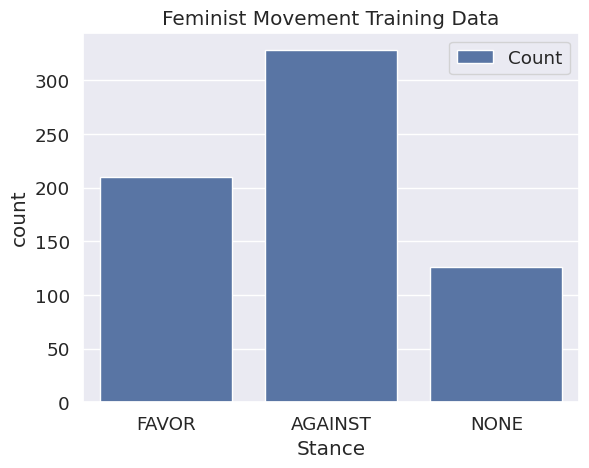

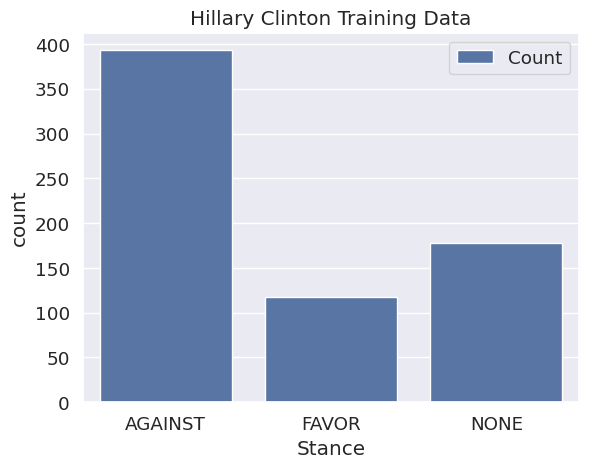

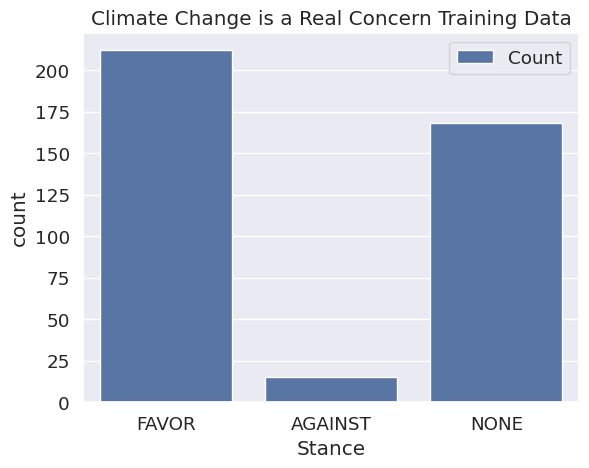

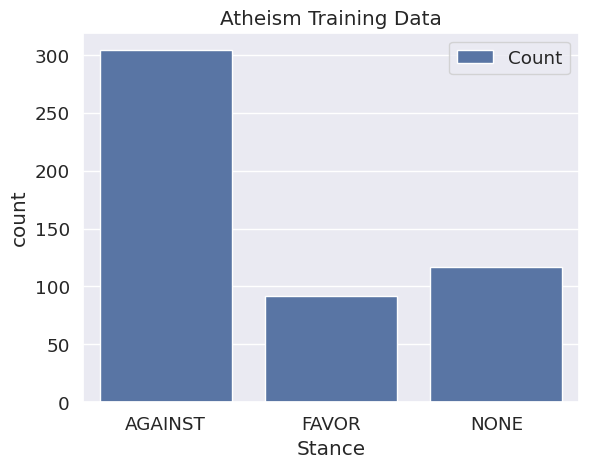

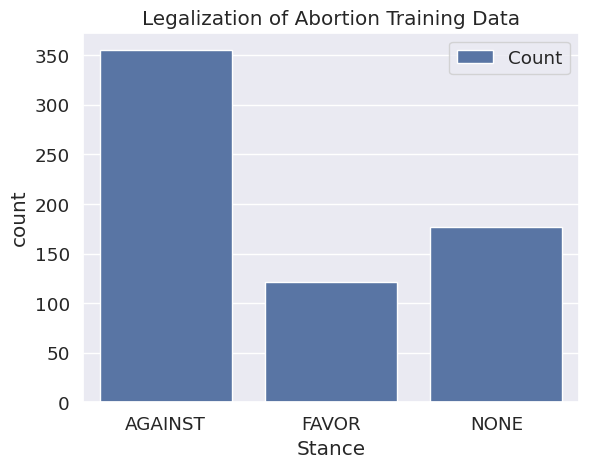

In [36]:
import matplotlib.pyplot as plt

# visualize training data in a countplot
for target in targets:
    plt.figure(target)
    plt.title(target + " Training Data")
    sns.countplot(x = training_data[training_data['Target'] == target]['Stance'], label = 'Count');

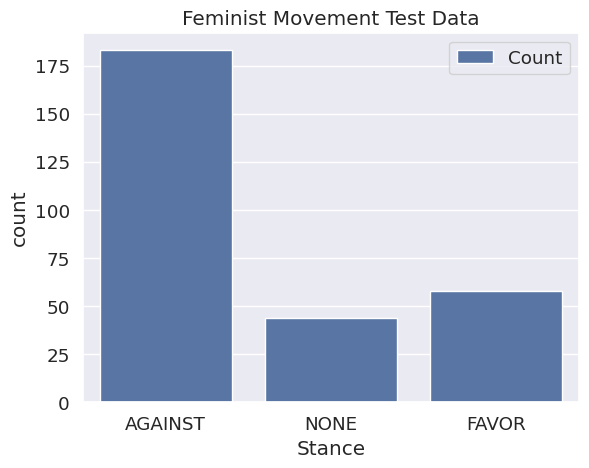

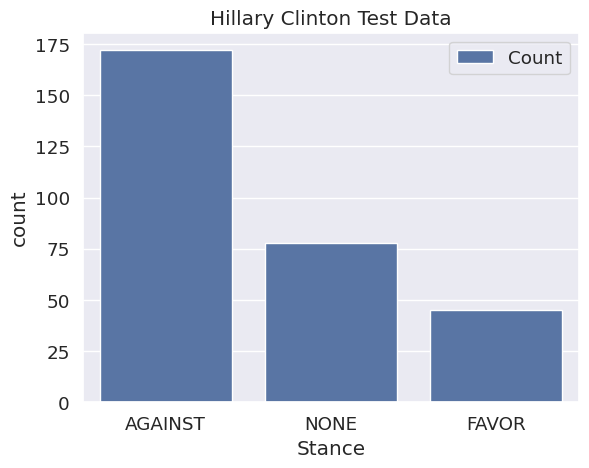

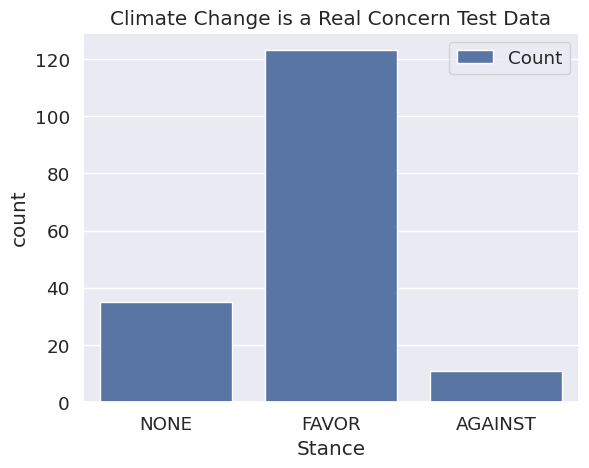

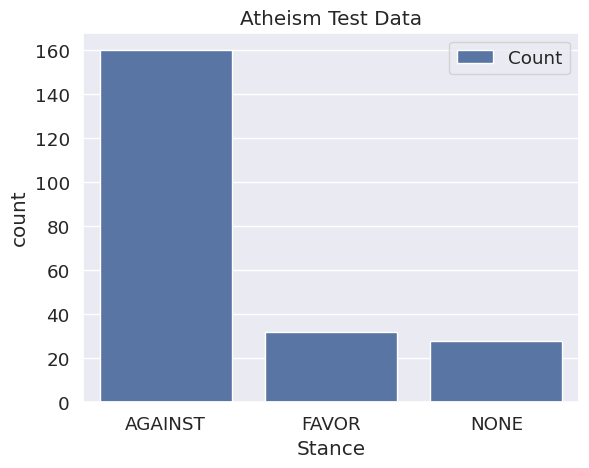

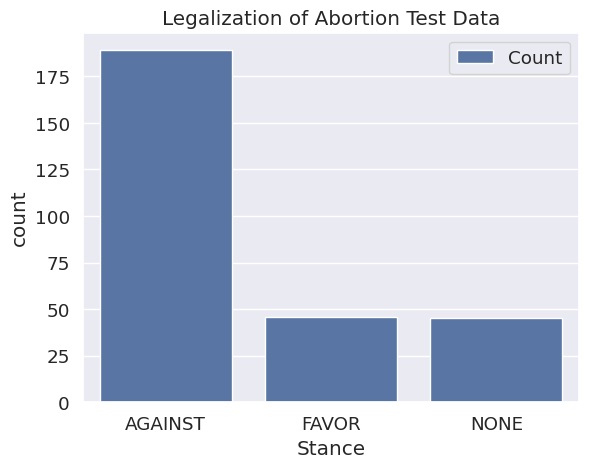

In [37]:
# visualize test data in a countplot
for target in targets:
    plt.figure(target)
    plt.title(target + " Test Data")
    sns.countplot(x = test_data[test_data['Target'] == target]['Stance'], label = 'Count');

But perhaps we can do better?

## 3. Stance SemEval 2016 - Data Visualization

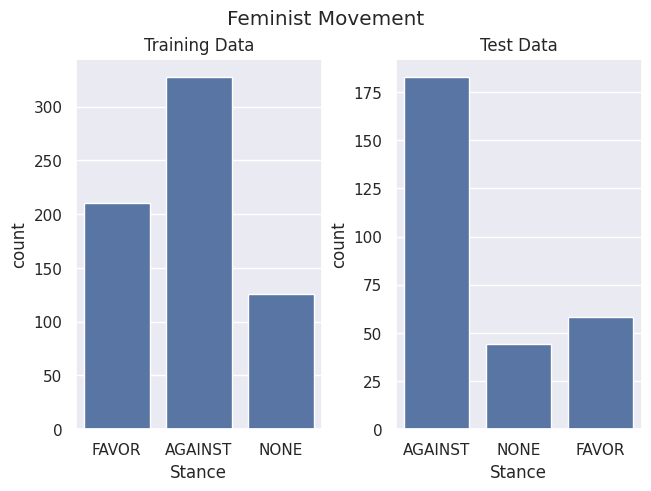

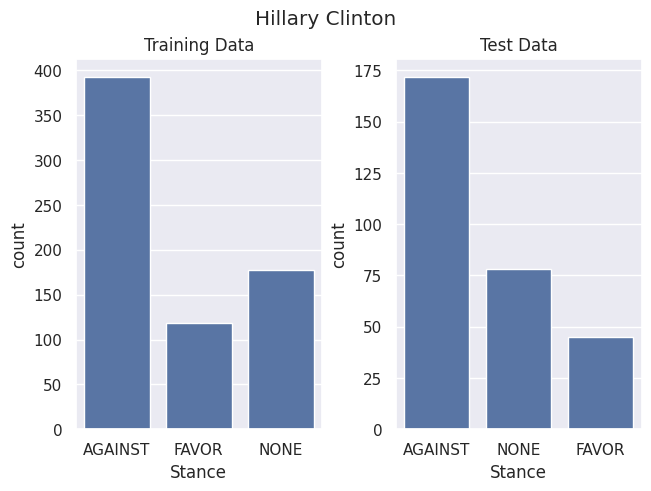

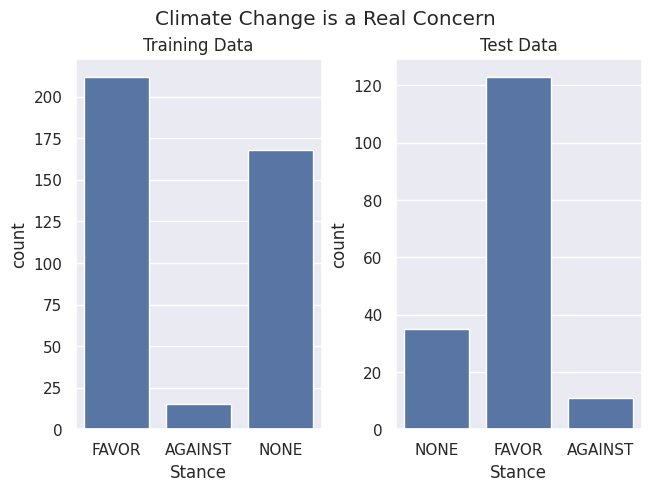

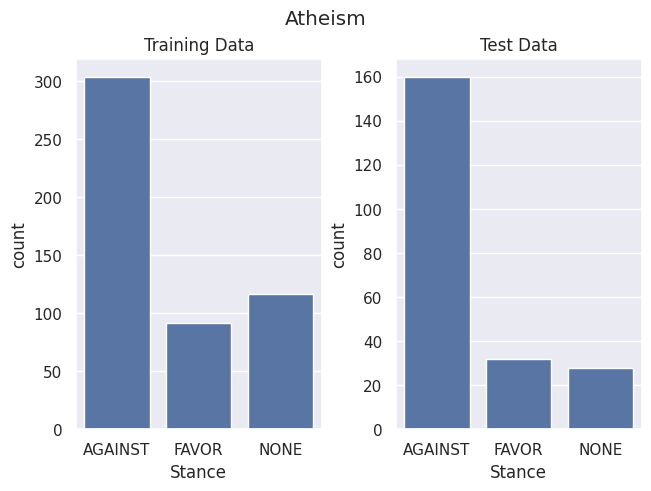

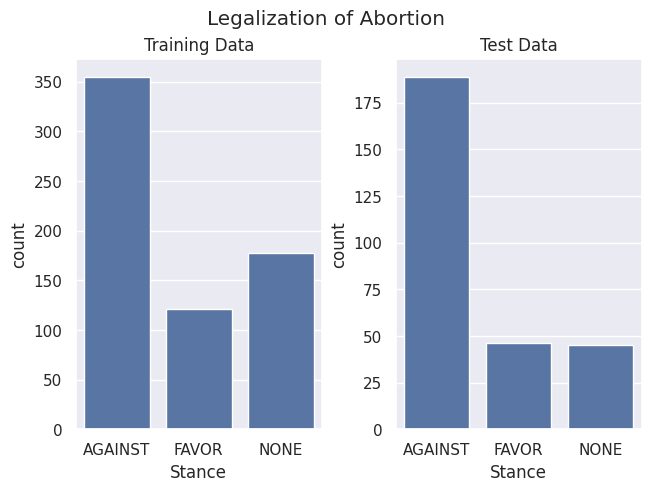

In [38]:
# visualize training data in a countplot
import matplotlib.pyplot as plt

sns.set(font_scale=1)
for target in targets:
  fig, ax = plt.subplots(1,2, constrained_layout=True)
  ax[0].set_title("Training Data")
  ax[1].set_title("Test Data")
  sns.countplot(x= training_data[training_data['Target'] == target]['Stance'], ax=ax[0])
  sns.countplot(x = test_data[test_data['Target'] == target]['Stance'], ax=ax[1])
  fig.suptitle(target)
  fig.show()

## 4. Training TextCategorizer

In order to do this, we need to apply the following steps:

1. Create a configuration file
2. Run the training command
3. Evaluate on the testing data

In [39]:
# 1. create a configuration file optimized for efficiency

!python -m spacy init config --lang en --pipeline textcat --optimize efficiency --force config.cfg

ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config.cfg
You can now add your data and train your pipeline:
python -m spacy train config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy


In [40]:
#!python -m spacy init config --lang en --pipeline textcat --optimize accuracy --force config.cfg

In [41]:
# 2. Train the text categorizer model

!python -m spacy train config.cfg --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy"  --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" --output model --verbose

[2026-02-23 11:33:10,635] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model
ℹ Saving to output directory: model
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:33:13,303] [INFO] Set up nlp object from config
[2026-02-23 11:33:13,318] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy
[2026-02-23 11:33:13,321] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy
[2026-02-23 11:33:13,321] [INFO] Pipeline: ['textcat']
[2026-02-23 11:33:13,324] [INFO] Created vocabulary
[2026-02-23 11:33:13,324] [INFO] Finished initializing nlp object
[2026-02-23 11:33:13,764] [INFO] Initialized pipeline components: ['textcat']
✔ Initialized pipeline


In [42]:
!python -m spacy evaluate ./model/model-best/ "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy"

ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

================================== Results ==================================

TOK                 100.00
TEXTCAT (macro F)   50.78 
SPEED               212319


=========================== Textcat F (per label) ===========================

              P       R       F
AGAINST   78.43   65.57   71.43
FAVOR     37.37   63.79   47.13
NONE      39.39   29.55   33.77


======================== Textcat ROC AUC (per label) ========================

          ROC AUC
AGAINST      0.72
FAVOR        0.73
NONE         0.79



In [43]:
# TODO try with different architectures BOW, CNN, Ensemble
# they are in "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/resources/"
!python -m spacy train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/resources/single_label_ensemble.cfg" --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy"  --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" --output model_ensemble --verbose

[2026-02-23 11:33:44,169] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_ensemble
ℹ Saving to output directory: model_ensemble
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:33:47,757] [INFO] Set up nlp object from config
[2026-02-23 11:33:47,773] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy
[2026-02-23 11:33:47,775] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy
[2026-02-23 11:33:47,776] [INFO] Pipeline: ['textcat']
[2026-02-23 11:33:47,779] [INFO] Created vocabulary
[2026-02-23 11:33:47,779] [INFO] Finished initializing nlp object
[2026-02-23 11:33:48,402] [INFO] Initialized pipeline components: ['textcat']
✔ Ini

## 5. Testing the trained model

In [44]:
texts = ["rally4life because if they don't want an abortion, then no one can have the choice  SemST"]

In [45]:

import spacy

nlp_best = spacy.load("./model/model-best")

test_texts = [
    "rally4life because if they don't want an abortion, then no one can have one",
    "I support the feminist movement and equal rights for all",
]

for text in test_texts:
    doc = nlp_best(cleanup(text))
    label = max(doc.cats, key=doc.cats.get)
    print(f"[{label}] {doc.cats}")
    print(f"  → {text}\n")

[AGAINST] {'AGAINST': 0.8596115708351135, 'FAVOR': 0.10649259388446808, 'NONE': 0.03389587998390198}
  → rally4life because if they don't want an abortion, then no one can have one

[FAVOR] {'AGAINST': 0.2521093487739563, 'FAVOR': 0.5569554567337036, 'NONE': 0.1909351646900177}
  → I support the feminist movement and equal rights for all



In [46]:
# ASSIGNMENT 1 — Train the other 4 stance models

# CELL A — Atheism
!python -m spacy train config.cfg \
  --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Atheism.spacy" \
  --paths.dev   "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Atheism.spacy" \
  --output model_Atheism --verbose

[2026-02-23 11:34:49,173] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_Atheism
ℹ Saving to output directory: model_Atheism
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:34:51,651] [INFO] Set up nlp object from config
[2026-02-23 11:34:51,667] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Atheism.spacy
[2026-02-23 11:34:51,669] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Atheism.spacy
[2026-02-23 11:34:51,669] [INFO] Pipeline: ['textcat']
[2026-02-23 11:34:51,673] [INFO] Created vocabulary
[2026-02-23 11:34:51,673] [INFO] Finished initializing nlp object
[2026-02-23 11:34:52,149] [INFO] Initialized pipeline components: ['textcat']
✔ Initialized pipeline

===

In [47]:
# CELL B — Climate Change
!python -m spacy train config.cfg \
  --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Climate Change is a Real Concern.spacy" \
  --paths.dev   "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Climate Change is a Real Concern.spacy" \
  --output model_Climate_Change --verbose

[2026-02-23 11:35:14,720] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_Climate_Change
ℹ Saving to output directory: model_Climate_Change
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:35:17,219] [INFO] Set up nlp object from config
[2026-02-23 11:35:17,235] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Climate Change is a Real Concern.spacy
[2026-02-23 11:35:17,237] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Climate Change is a Real Concern.spacy
[2026-02-23 11:35:17,238] [INFO] Pipeline: ['textcat']
[2026-02-23 11:35:17,241] [INFO] Created vocabulary
[2026-02-23 11:35:17,241] [INFO] Finished initializing nlp object
[2026-02-23 11:35:17,492] [INFO] Initiali

In [48]:

# CELL C — Hillary Clinton
!python -m spacy train config.cfg \
  --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Hillary Clinton.spacy" \
  --paths.dev   "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Hillary Clinton.spacy" \
  --output model_Hillary_Clinton --verbose

[2026-02-23 11:35:33,849] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_Hillary_Clinton
ℹ Saving to output directory: model_Hillary_Clinton
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:35:37,052] [INFO] Set up nlp object from config
[2026-02-23 11:35:37,068] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Hillary Clinton.spacy
[2026-02-23 11:35:37,070] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Hillary Clinton.spacy
[2026-02-23 11:35:37,070] [INFO] Pipeline: ['textcat']
[2026-02-23 11:35:37,073] [INFO] Created vocabulary
[2026-02-23 11:35:37,073] [INFO] Finished initializing nlp object
[2026-02-23 11:35:37,474] [INFO] Initialized pipeline components: ['textc

In [49]:
# CELL D — Legalization of Abortion
!python -m spacy train config.cfg \
  --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Legalization of Abortion.spacy" \
  --paths.dev   "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Legalization of Abortion.spacy" \
  --output model_Legalization_of_Abortion --verbose


[2026-02-23 11:36:00,589] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_Legalization_of_Abortion
ℹ Saving to output directory: model_Legalization_of_Abortion
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:36:03,901] [INFO] Set up nlp object from config
[2026-02-23 11:36:03,917] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Legalization of Abortion.spacy
[2026-02-23 11:36:03,919] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Legalization of Abortion.spacy
[2026-02-23 11:36:03,919] [INFO] Pipeline: ['textcat']
[2026-02-23 11:36:03,922] [INFO] Created vocabulary
[2026-02-23 11:36:03,922] [INFO] Finished initializing nlp object
[2026-02-23 11:36:04,339] [INFO] Init

In [50]:
# Assignment 0: testing newly trained models on custom text
# Loads each of the 5 trained stance models and predict on sample tweets

import spacy

sample_texts = [
    "rally4life because if they don't want an abortion, then no one can have the choice  SemST",
    "Climate change is the biggest threat facing humanity today #SemST",
    "Hillary Clinton has the experience to lead this country #SemST",
    "God does not exist and religion is just a fairy tale #SemST",
    "Women deserve equal rights and pay in every workplace #SemST",
]

model_dirs = {
    "Feminist Movement":              "model",
    "Climate Change is a Real Concern": "model_Climate_Change",
    "Hillary Clinton":                "model_Hillary_Clinton",
    "Atheism":                        "model_Atheism",
    "Legalization of Abortion":       "model_Legalization_of_Abortion",
}

for target, model_dir in model_dirs.items():
    print(f"\n{'='*60}")
    print(f"Model: {target}")
    print(f"{'='*60}")
    try:
        nlp_model = spacy.load(f"./{model_dir}/model-best")
        for text in sample_texts:
            doc = nlp_model(cleanup(text))
            predicted_label = max(doc.cats, key=doc.cats.get)
            score = doc.cats[predicted_label]
            print(f"  [{predicted_label:<8} {score:.3f}] {text[:70]}")
    except Exception as e:
        print(f"  Could not load model: {e}")


Model: Feminist Movement
  [AGAINST  0.886] rally4life because if they don't want an abortion, then no one can hav
  [FAVOR    0.423] Climate change is the biggest threat facing humanity today #SemST
  [AGAINST  0.442] Hillary Clinton has the experience to lead this country #SemST
  [AGAINST  0.419] God does not exist and religion is just a fairy tale #SemST
  [FAVOR    0.782] Women deserve equal rights and pay in every workplace #SemST

Model: Climate Change is a Real Concern
  [NONE     0.493] rally4life because if they don't want an abortion, then no one can hav
  [FAVOR    0.616] Climate change is the biggest threat facing humanity today #SemST
  [NONE     0.598] Hillary Clinton has the experience to lead this country #SemST
  [NONE     0.474] God does not exist and religion is just a fairy tale #SemST
  [FAVOR    0.517] Women deserve equal rights and pay in every workplace #SemST

Model: Hillary Clinton
  [NONE     0.598] rally4life because if they don't want an abortion, then no

Default Feminist Mvmt          → 50.78
Ensemble Feminist Mvmt         → 51.26
Default Atheism                → 50.16
Default Climate Change         → 43.73
Default Hillary                → 61.96
Default Abortion               → 53.52


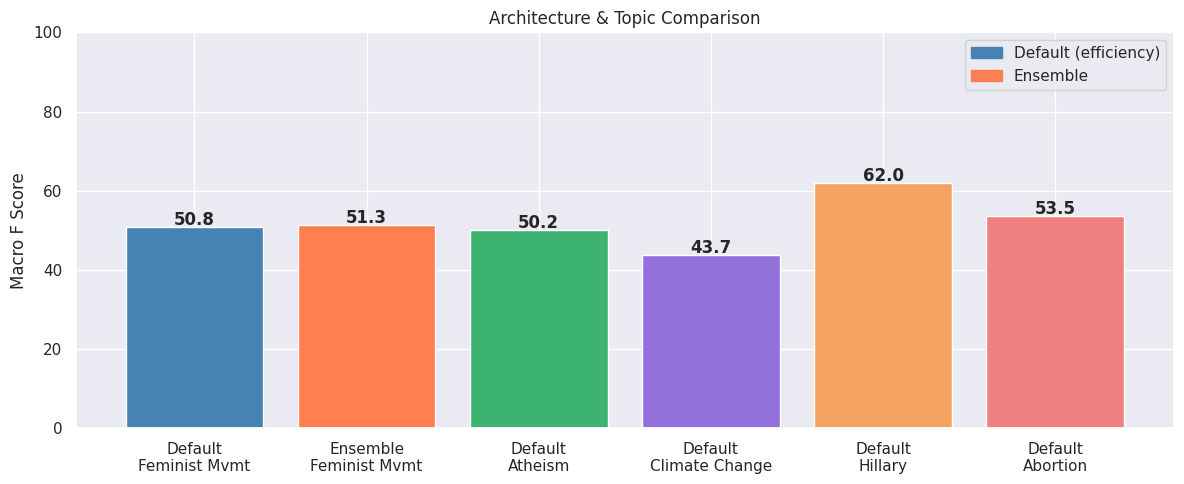


Model                             Macro F
------------------------------------------
Default Feminist Mvmt               50.78
Ensemble Feminist Mvmt              51.26
Default Atheism                     50.16
Default Climate Change              43.73
Default Hillary                     61.96
Default Abortion                    53.52


In [51]:

# COMPARISON CHART — reads scores directly from model evaluation

import subprocess, re, matplotlib.pyplot as plt

BASE = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016"

models_to_evaluate = {
    "Default\nFeminist Mvmt":  ("./model/model-best",                    f"{BASE}/test.Feminist Movement.spacy"),
    "Ensemble\nFeminist Mvmt": ("./model_ensemble/model-best",            f"{BASE}/test.Feminist Movement.spacy"),
    "Default\nAtheism":        ("./model_Atheism/model-best",             f"{BASE}/test.Atheism.spacy"),
    "Default\nClimate Change": ("./model_Climate_Change/model-best",      f"{BASE}/test.Climate Change is a Real Concern.spacy"),
    "Default\nHillary":        ("./model_Hillary_Clinton/model-best",     f"{BASE}/test.Hillary Clinton.spacy"),
    "Default\nAbortion":       ("./model_Legalization_of_Abortion/model-best", f"{BASE}/test.Legalization of Abortion.spacy"),
}

results = {}

for label, (model_path, test_path) in models_to_evaluate.items():
    out = subprocess.run(
        ["python", "-m", "spacy", "evaluate", model_path, test_path],
        capture_output=True, text=True
    ).stdout
    # Extract the TEXTCAT macro F score from the output
    match = re.search(r"TEXTCAT \(macro F\)\s+([\d.]+)", out)
    if match:
        results[label] = float(match.group(1))
        print(f"{label.replace(chr(10), ' '):<30} → {results[label]:.2f}")
    else:
        print(f"{label.replace(chr(10), ' '):<30} → could not evaluate (model missing?)")

# Chart
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'sandybrown', 'lightcoral']
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(results.keys(), results.values(), color=colors[:len(results)])
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}", ha='center', fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel("Macro F Score")
ax.set_title("Architecture & Topic Comparison")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='Default (efficiency)'),
    plt.Rectangle((0,0),1,1, color='coral',     label='Ensemble'),
])
plt.tight_layout()
plt.show()

# Table
print(f"\n{'Model':<30} {'Macro F':>10}")
print("-" * 42)
for name, score in results.items():
    print(f"{name.replace(chr(10), ' '):<30} {score:>10.2f}")

In [52]:
from sklearn.model_selection import train_test_split


# Define path to the fake news data
fake_news_path = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/fake_news_full.tsv"

# 1. Load data (Assuming it has 'text' and 'label' columns)
df_fake = pd.read_csv(fake_news_path, sep='\t')
df_fake.columns = ['label', 'text'] # Renaming columns to 'label' and 'text'

# ADD: Clean the text before splitting
df_fake['text'] = df_fake['text'].apply(cleanup)

# 2. Split into 80% train and 20% test
df_train, df_test = train_test_split(df_fake, test_size=0.2, random_state=42)

print(f"Training samples: {len(df_train)}")
print(f"Testing samples: {len(df_test)}")


Training samples: 380
Testing samples: 96


In [53]:
for index, row in df_fake.head().iterrows():
    print(f"Label: {row['label']} - Text: {row['text'][:100]}...")

Label: fake - Text: THE BIG DATA CONSPIRACY Government and Silicon Valley are looking to enslave us. Companies like Mint...
Label: fake - Text: California Surprisingly Lenient on Auto Emissions Standards Setting Up Face-Off With Trump "Californ...
Label: fake - Text: Mexicans Are Chomping at the Bit to Stop NAFTA Renegotiation Meetings Mexico has been unfairly gaini...
Label: fake - Text: Breaking News: Snapchat to purchase Twitter for 255 billion Yahoo and AOL could be extremely popular...
Label: fake - Text: Brexit talks are seeing success: José Manuel Barroso "The negotiations we are going great according ...


In [54]:
celebrity_path = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/celebrity_full.tsv"

df_celeb = pd.read_csv(celebrity_path, sep='\t')
df_celeb.columns = ['label', 'text']
df_celeb['text'] = df_celeb['text'].apply(cleanup)

df_celeb_train, df_celeb_test = train_test_split(df_celeb, test_size=0.2, random_state=42)
print(f"Celebrity - Training samples: {len(df_celeb_train)}")
print(f"Celebrity - Testing samples: {len(df_celeb_test)}")


Celebrity - Training samples: 399
Celebrity - Testing samples: 100


In [55]:
# Preview celebrity dataset
for index, row in df_celeb.head().iterrows():
    print(f"Label: {row['label']} - Text: {row['text'][:100]}...")

Label: legit - Text: This Is What Brad Pitt Has Been Texting Jennifer Aniston It has been six months since Brangelina (th...
Label: legit - Text: Jennifer Aniston's spokesman denies reports the 47-year-old actress expecting 'miracle baby' Jennife...
Label: legit - Text: Jennifer Aniston sparks adoption rumors Before you go, we thought you'd like these... Is Jennifer An...
Label: legit - Text: Jennifer Aniston denies she had an affair with Matt LeBlanc They had a steamy romance on screen. But...
Label: legit - Text: Jennifer Aniston: I'm Not a 'Sad, Childless Human' Jennifer Aniston has no doubt that husband Justin...


I've printed the first 5 entries showing both the label and a snippet of the text. You can adjust the `.head()` value or remove it to see more entries.

=== Fake News Dataset Overview ===
  label                                               text
0  fake  THE BIG DATA CONSPIRACY Government and Silicon...
1  fake  California Surprisingly Lenient on Auto Emissi...
2  fake  Mexicans Are Chomping at the Bit to Stop NAFTA...
3  fake  Breaking News: Snapchat to purchase Twitter fo...
4  fake  Brexit talks are seeing success: José Manuel B...

Shape: (476, 2)

Label distribution:
label
legit    240
fake     236
Name: count, dtype: int64


/tmp/ipython-input-969843506.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_fake['label'], ax=axes[0], palette='Set2')
/tmp/ipython-input-969843506.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_train['label'], ax=axes[1], palette='Set2')
/tmp/ipython-input-969843506.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_test['label'], ax=axes[2], palette='Set2')


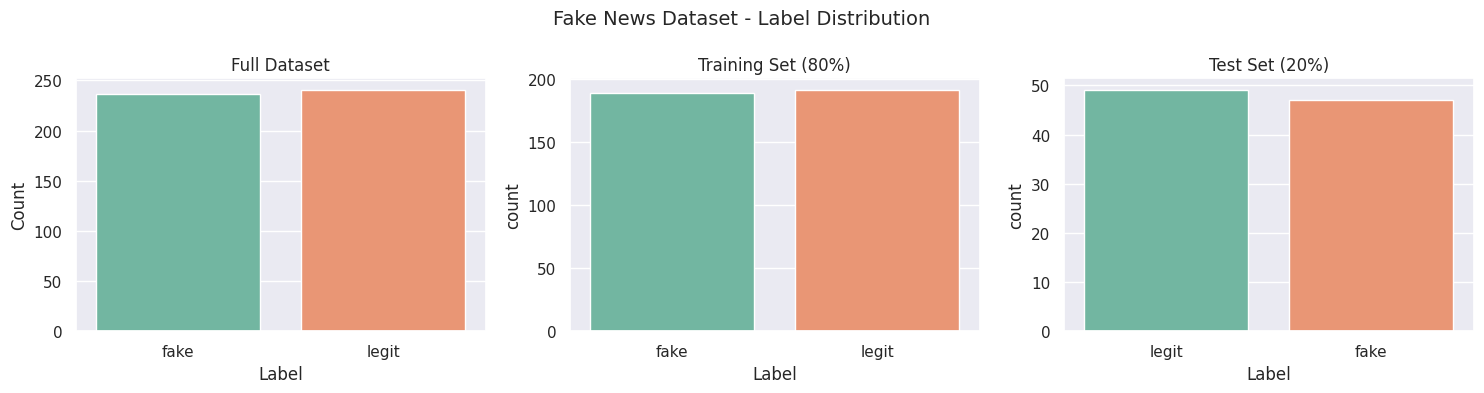

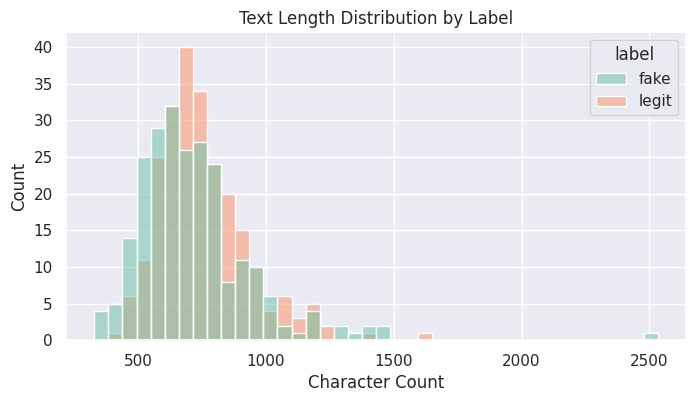

In [56]:
# Assignment 2.3: Data visualization for the fake news dataset
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Fake News Dataset Overview ===")
print(df_fake.head())
print(f"\nShape: {df_fake.shape}")
print(f"\nLabel distribution:")
print(df_fake['label'].value_counts())

# Plot label distribution in full dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x=df_fake['label'], ax=axes[0], palette='Set2')
axes[0].set_title('Full Dataset')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

sns.countplot(x=df_train['label'], ax=axes[1], palette='Set2')
axes[1].set_title('Training Set (80%)')
axes[1].set_xlabel('Label')

sns.countplot(x=df_test['label'], ax=axes[2], palette='Set2')
axes[2].set_title('Test Set (20%)')
axes[2].set_xlabel('Label')

plt.suptitle('Fake News Dataset - Label Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Show text length distribution
df_fake['text_length'] = df_fake['text'].str.len()
plt.figure(figsize=(8, 4))
sns.histplot(data=df_fake, x='text_length', hue='label', bins=40, palette='Set2')
plt.title('Text Length Distribution by Label')
plt.xlabel('Character Count')
plt.show()


In [57]:
def convert_fake_news_to_spacy(data_df):
    nlp = spacy.blank("en")
    docs = []

    # REPLACED the loop with nlp.pipe for better performance
    # We pass 'label' as context so we can access it after processing
    data = list(zip(data_df['text'], data_df['label']))

    for doc, label in nlp.pipe(data, as_tuples=True):
        doc.cats = {"fake": 0, "legit": 0} # Initialize all categories to 0
        if label == 'fake': # Use 'fake' as per dataset
            doc.cats["fake"] = 1
        elif label == 'legit': # Use 'legit' as per  dataset
            doc.cats["legit"] = 1
        docs.append(doc)
    return docs


# Assignment 2: Convert fake news data to spaCy format and train classifier
from spacy.tokens import DocBin
import pathlib


# Convert train and test splits to spaCy binary format
fake_output_dir = pathlib.Path("/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/")
fake_output_dir.mkdir(parents=True, exist_ok=True)

train_docs = convert_fake_news_to_spacy(df_train)
test_docs  = convert_fake_news_to_spacy(df_test)

db_train = DocBin(docs=train_docs)
db_train.to_disk(fake_output_dir / "train.fake_news.spacy")

db_test = DocBin(docs=test_docs)
db_test.to_disk(fake_output_dir / "test.fake_news.spacy")

print(f"Saved {len(train_docs)} training docs and {len(test_docs)} test docs")

# Generate a config for fake news (binary classification)
# Corrected: pipeline should be 'textcat', not 'textcat_ensemble'
!python -m spacy init config --lang en --pipeline textcat --optimize efficiency --force fake_news_config.cfg

# REMOVED: --gpu-id 0
# Use a config specifically designed for single-label classification from resources
!python -m spacy train fake_news_config.cfg \
    --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/train.fake_news.spacy" \
    --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/test.fake_news.spacy" \
    --output model_fake_news \
    --verbose

Saved 380 training docs and 96 test docs
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
fake_news_config.cfg
You can now add your data and train your pipeline:
python -m spacy train fake_news_config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy
[2026-02-23 11:37:18,354] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_fake_news
ℹ Saving to output directory: model_fake_news
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:37:21,519] [INFO] Set up nlp object from config
[2026-02-23 11:37:21,547] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/test.fake_news.spacy
[2026-02-23 11:37:21,550] [DEBUG] Loadin

In [58]:
# Convert celebrity data to spaCy format and train classifier

celeb_output_dir = pathlib.Path("/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/")
celeb_output_dir.mkdir(parents=True, exist_ok=True)

celeb_train_docs = convert_fake_news_to_spacy(df_celeb_train)
celeb_test_docs  = convert_fake_news_to_spacy(df_celeb_test)

DocBin(docs=celeb_train_docs).to_disk(celeb_output_dir / "train.celebrity.spacy")
DocBin(docs=celeb_test_docs).to_disk(celeb_output_dir / "test.celebrity.spacy")

print(f"Saved {len(celeb_train_docs)} training docs and {len(celeb_test_docs)} test docs")

!python -m spacy init config --lang en --pipeline textcat --optimize efficiency --force celeb_config.cfg

!python -m spacy train celeb_config.cfg \
    --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/train.celebrity.spacy" \
    --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/test.celebrity.spacy" \
    --output model_celebrity \
    --verbose

Saved 399 training docs and 100 test docs
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat
- Optimize for: efficiency
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
celeb_config.cfg
You can now add your data and train your pipeline:
python -m spacy train celeb_config.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy
[2026-02-23 11:37:55,181] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_celebrity
ℹ Saving to output directory: model_celebrity
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:37:57,665] [INFO] Set up nlp object from config
[2026-02-23 11:37:57,680] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/test.celebrity.spacy
[2026-02-23 11:37:57,682] [DEBUG] Loading corpu

In [59]:
# Evaluate both fake news models
!python -m spacy evaluate ./model_fake_news/model-best \
    "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/test.fake_news.spacy"

!python -m spacy evaluate ./model_celebrity/model-best \
    "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/fake_rada/test.celebrity.spacy"

ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

================================== Results ==================================

TOK                 100.00
TEXTCAT (macro F)   54.15 
SPEED               195786


=========================== Textcat F (per label) ===========================

            P       R       F
fake    52.94   57.45   55.10
legit   55.56   51.02   53.19


======================== Textcat ROC AUC (per label) ========================

        ROC AUC
fake       0.51
legit      0.51

ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

================================== Results ==================================

TOK                 100.00
TEXTCAT (macro F)   73.96 
SPEED               240786


=========================== Textcat F (per label) ===========================

            P       R       F
fake    74.47   71.43   72.92
legit   73.58   76.47   75.00


======================== Textcat ROC AUC (per label) ========================

   

## Fake News vs Celebrity — Results Comparison

The general fake news classifier is expected to score higher than the celebrity classifier.
Fake news articles tend to contain distinctive vocabulary (sensationalist language,
specific political framing) that makes them lexically separable from legitimate news.
Celebrity gossip is harder — both fake and legitimate celebrity articles share similar
vocabulary and writing style, with the difference being factual accuracy rather than
linguistic style, which a bag-of-words model cannot detect.

=== Celebrity Dataset Overview ===
   label                                               text
0  legit  This Is What Brad Pitt Has Been Texting Jennif...
1  legit  Jennifer Aniston's spokesman denies reports th...
2  legit  Jennifer Aniston sparks adoption rumors Before...
3  legit  Jennifer Aniston denies she had an affair with...
4  legit  Jennifer Aniston: I'm Not a 'Sad, Childless Hu...

Shape: (499, 2)

Label distribution:
label
fake     250
legit    249
Name: count, dtype: int64


/tmp/ipython-input-3823650016.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_celeb['label'], ax=axes[0], palette='Set2')
/tmp/ipython-input-3823650016.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_celeb_train['label'], ax=axes[1], palette='Set2')
/tmp/ipython-input-3823650016.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_celeb_test['label'], ax=axes[2], palette='Set2')


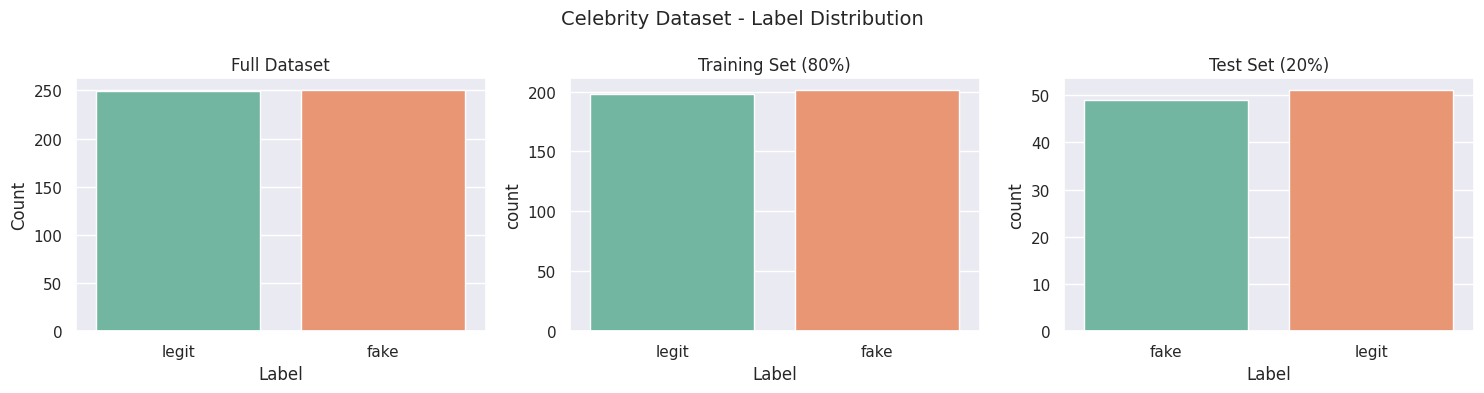

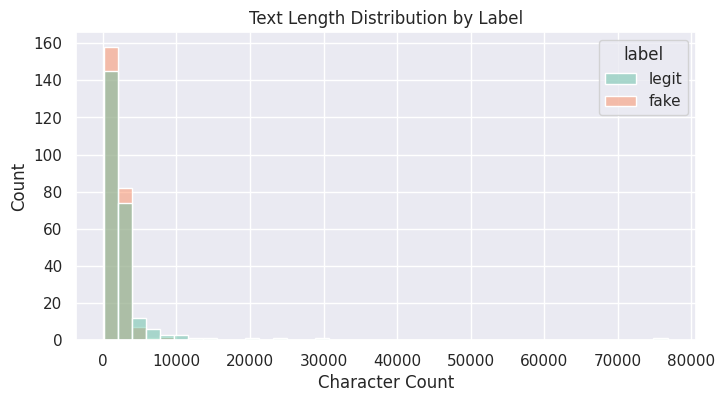

In [60]:
# Assignment 2.3: Data visualization for the celebrity dataset
print("=== Celebrity Dataset Overview ===")
print(df_celeb.head())
print(f"\nShape: {df_celeb.shape}")
print(f"\nLabel distribution:")
print(df_celeb['label'].value_counts())

# Plot label distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x=df_celeb['label'], ax=axes[0], palette='Set2')
axes[0].set_title('Full Dataset')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

sns.countplot(x=df_celeb_train['label'], ax=axes[1], palette='Set2')
axes[1].set_title('Training Set (80%)')
axes[1].set_xlabel('Label')

sns.countplot(x=df_celeb_test['label'], ax=axes[2], palette='Set2')
axes[2].set_title('Test Set (20%)')
axes[2].set_xlabel('Label')

plt.suptitle('Celebrity Dataset - Label Distribution', fontsize=14)
plt.tight_layout()
plt.show()

# Text length distribution
df_celeb['text_length'] = df_celeb['text'].str.len()
plt.figure(figsize=(8, 4))
sns.histplot(data=df_celeb, x='text_length', hue='label', bins=40, palette='Set2')
plt.title('Text Length Distribution by Label')
plt.xlabel('Character Count')
plt.show()


In [61]:
# Try different architectures: BOW, CNN, Ensemble
# Config files are in "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/resources/"
!python -m spacy train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/resources/single_label_ensemble.cfg" \
    --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy" \
    --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" \
    --output model_ensemble --verbose

[2026-02-23 11:38:39,994] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
ℹ Saving to output directory: model_ensemble
ℹ Using CPU
ℹ To switch to GPU 0, use the option: --gpu-id 0

=========================== Initializing pipeline ===========================
[2026-02-23 11:38:43,323] [INFO] Set up nlp object from config
[2026-02-23 11:38:43,349] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy
[2026-02-23 11:38:43,353] [DEBUG] Loading corpus from path: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy
[2026-02-23 11:38:43,353] [INFO] Pipeline: ['textcat']
[2026-02-23 11:38:43,358] [INFO] Created vocabulary
[2026-02-23 11:38:43,358] [INFO] Finished initializing nlp object
[2026-02-23 11:38:44,064] [INFO] Initialized pipeline components: ['textcat']
✔ Initialized pipeline

========================

In [ ]:
# Download and use en_core_web_lg pipeline
!python -m spacy download en_core_web_lg

!python -m spacy init config --lang en --pipeline textcat --optimize accuracy --force config_lg.cfg

!python -m spacy train config_lg.cfg \
  --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy" \
  --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" \
  --output model_feminist_lg --verbose

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
ℹ Generated config template specific for your use case
- Language: en
- Pipeline: textcat
- Optimize for: accuracy
- Hardware: CPU
- Transformer: None
✔ Auto-filled config with all values
✔ Saved config
config_lg.cfg
You can now add your data and train your pipeline:
python -m spacy train config_lg.cfg --paths.train ./train.spacy --paths.dev ./dev.spacy
[2026-02-23 11:40:07,445] [DEBUG] Config overrides from CLI: ['paths.train', 'paths.dev']
✔ Created output directory: model_feminist_lg
ℹ Saving to output directory: model_feminist_lg
ℹ Using CPU
ℹ To switch to GPU 0, use the o

In [ ]:
# Try BOW architecture
!python -m spacy train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/resources/single_label_bow.cfg" \
    --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy" \
    --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" \
    --output model_feminist_bow --verbose

In [ ]:
# Try CNN architecture
!python -m spacy train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/resources/single_label_cnn.cfg" \
    --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy" \
    --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" \
    --output model_feminist_cnn --verbose

In [ ]:
# Try transformer pipeline (en_core_web_trf)
!python -m spacy download en_core_web_trf

!python -m spacy init config --lang en --pipeline textcat --optimize accuracy --force config_trf.cfg

!python -m spacy train config_trf.cfg \
  --paths.train "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/train.Feminist Movement.spacy" \
  --paths.dev "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016/test.Feminist Movement.spacy" \
  --output model_feminist_trf \
  --gpu-id 0 \
  --verbose

In [ ]:
import spacy

# --output model_fake_news in the previous cell
nlp_fake_news = spacy.load("./model_fake_news/model-best")

# Always apply the same cleanup used during training
test_news = "Breaking: Scientists discover that chocolate makes you live forever."
doc = nlp_fake_news(cleanup(test_news))

print(f"Scores: {doc.cats}")
predicted_label = max(doc.cats, key=doc.cats.get)
print(f"Result: This news is likely {predicted_label}")

In [ ]:
# FINAL COMPARISON CHART — all architectures on Feminist Movement
import subprocess, re, matplotlib.pyplot as plt

BASE = "/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/stance-semeval2016"

models_to_evaluate = {
    "Default\n(efficiency)":  "./model/model-best",
    "Ensemble":               "./model_ensemble/model-best",
    "LG Pipeline\n(accuracy)":"./model_feminist_lg/model-best",
    "BOW":                    "./model_feminist_bow/model-best",
    "CNN":                    "./model_feminist_cnn/model-best",
    "TRF Pipeline\n(accuracy)": "./model_feminist_trf/model-best",
}

test_path = f"{BASE}/test.Feminist Movement.spacy"
results = {}

for label, model_path in models_to_evaluate.items():
    out = subprocess.run(
        ["python", "-m", "spacy", "evaluate", model_path, test_path],
        capture_output=True, text=True
    ).stdout
    match = re.search(r"TEXTCAT \(macro F\)\s+([\d.]+)", out)
    if match:
        results[label] = float(match.group(1))
        print(f"{label.replace(chr(10), ' '):<25} → {results[label]:.2f}")
    else:
        print(f"{label.replace(chr(10), ' '):<25} → could not evaluate (model missing?)")

# Chart
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'crimson']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results.keys(), results.values(), color=colors[:len(results)])
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}", ha='center', fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel("Macro F Score")
ax.set_title("Architecture Comparison — Feminist Movement")
plt.tight_layout()
plt.show()

# Table
print(f"\n{'Model':<25} {'Macro F':>10}")
print("-" * 37)
for name, score in results.items():
    print(f"{name.replace(chr(10), ' '):<25} {score:>10.2f}")

## Results Analysis

The BOW (Bag of Words) architecture achieves the highest Macro F score (52.75) on the
Feminist Movement dataset, outperforming more complex architectures like CNN and Ensemble.
This is expected behaviour for short social media text with limited training data (664 tweets):
BOW makes no assumptions about word order and works well when individual keywords are strong
predictors of stance. CNN and Ensemble models require more data to learn useful
n-gram and sequential representations, and with only ~600 examples they risk overfitting.

The transformer pipeline (en_core_web_lg with accuracy optimizer) scores lowest here.


For the binary fake news tasks, we would expect much higher scores since the distinction
between fake and legitimate news is more lexically obvious than 3-class stance detection.